# importing libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.callbacks import EarlyStopping
import random

# loading dataset

In [ ]:
df = pd.read_csv('Question4.csv')

# number of NaNs
nan_counts = df.isna().sum()

print("Number of NaNs in each column:")
print(nan_counts)

Number of NaNs in each column:
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


# correlation matrix

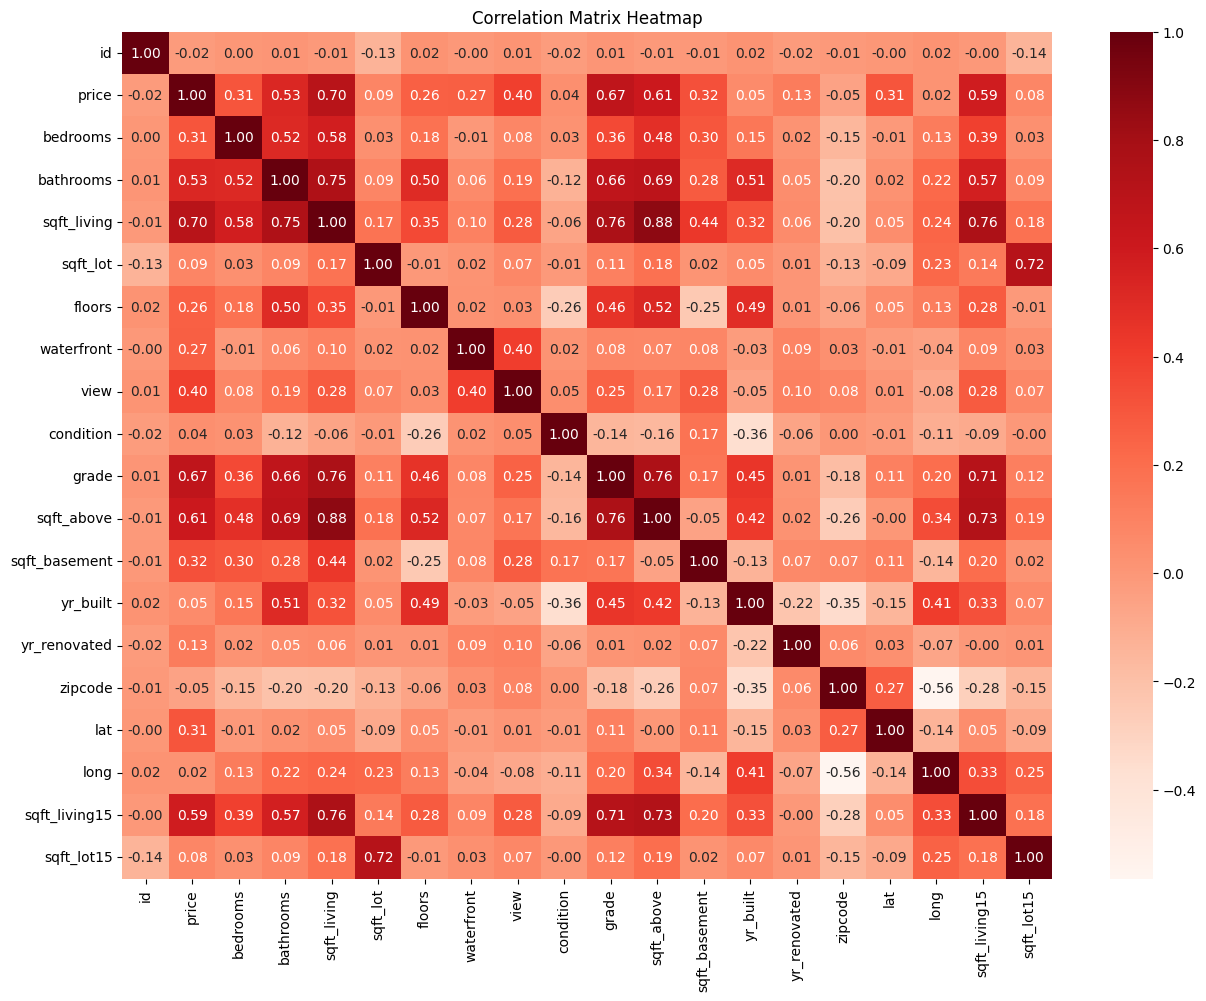

Features with highest correlation to 'price':
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
id              -0.016762
zipcode         -0.053203
Name: price, dtype: float64


In [ ]:
numeric_cols = df.select_dtypes(include=[np.number])
# correlation matrix
corr_matrix = numeric_cols.corr()

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(15, 11))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Reds')
plt.title('Correlation Matrix Heatmap')
plt.show()

# features with highest correlation with price
corr_with_price = corr_matrix['price'].drop('price').sort_values(ascending=False)
print("Features with highest correlation to 'price':")
print(corr_with_price)

# price distribution

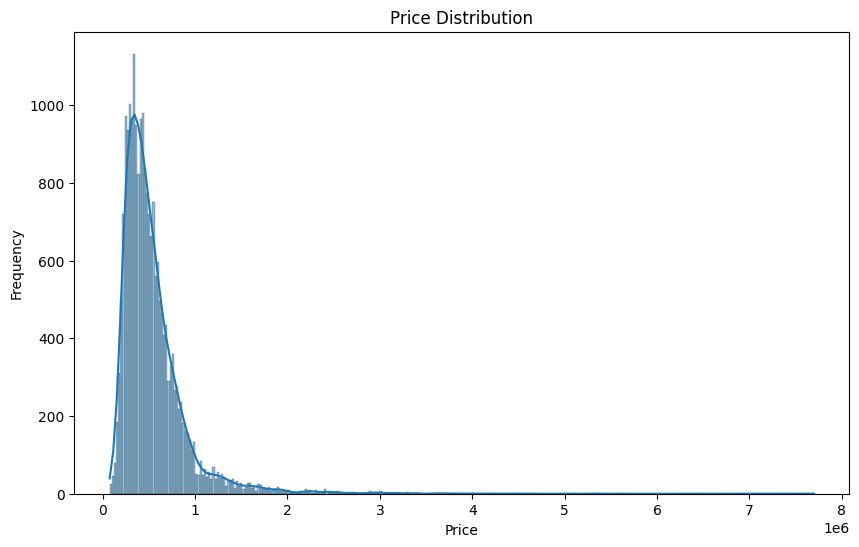

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'].dropna(), kde=True)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# plotting price and highest correlations with price

Feature with the highest correlation with 'price': sqft_living


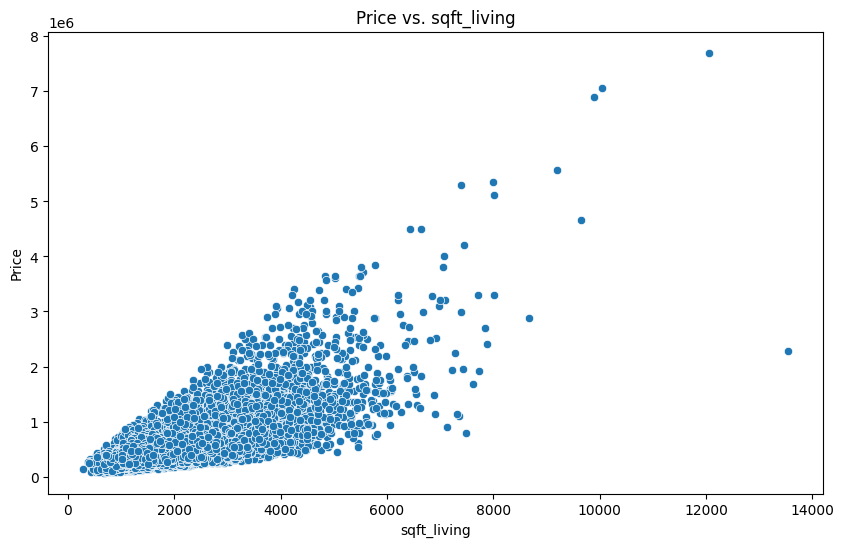

In [ ]:
highest_corr_feature = corr_with_price.idxmax()
print(f"Feature with the highest correlation with 'price': {highest_corr_feature}")

# plot of price vs. highest correlated feature
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x=highest_corr_feature, y='price')
plt.title(f"Price vs. {highest_corr_feature}")
plt.xlabel(highest_corr_feature)
plt.ylabel('Price')
plt.show()

# data preprocessing
- converting the date column to year and month
- removing the date column after converting

In [ ]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df = df.drop(columns=['date'])

# seperating date to train and validation

In [ ]:
# features input (X) and target variable (y)
X = df.drop(columns=['price'])
y = df['price']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)
X_train = X_train.fillna(X_train.mean())
X_val = X_val.fillna(X_val.mean())

# scaling data using MinMaxScaler

In [ ]:
scaler_train = MinMaxScaler()
scaler_val = MinMaxScaler()
X_train_scaled = scaler_train.fit_transform(X_train)
X_val_scaled = scaler_val.fit_transform(X_val)

Training and validation data have been scaled separately using MinMaxScaler.


# converting categories to numerical vraiables using one-hot

In [ ]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
X_combined = pd.concat([X_train, X_val], axis=0)
X_combined_encoded = pd.get_dummies(X_combined, columns=categorical_cols, drop_first=True)

# Split back into training and validation sets
X_train_encoded = X_combined_encoded.iloc[:X_train.shape[0], :]
X_val_encoded = X_combined_encoded.iloc[X_train.shape[0]:, :]
X_train_scaled = scaler_train.fit_transform(X_train_encoded)
X_val_scaled = scaler_val.fit_transform(X_val_encoded)

# defingin target y with logarithmic transformation on target for better results on the model

In [ ]:
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

# first mlp model with one hidden layer and 64 nodes and adam optimization function

In [ ]:
input_dim = X_train_scaled.shape[1]

model_single_layer = keras.Sequential([layers.Dense(64, activation='relu', input_shape=(input_dim,)),layers.Dense(1)])

model_single_layer.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# training the first mlp model for 20 epochs

In [ ]:
history_single_layer = model_single_layer.fit( X_train_scaled, y_train_log, epochs=20,batch_size=32,validation_data=(X_val_scaled, y_val_log),verbose=1)

Epoch 1/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 66.7657 - mean_absolute_error: 6.5839 - val_loss: 1.6286 - val_mean_absolute_error: 1.0152
Epoch 2/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.2460 - mean_absolute_error: 0.8924 - val_loss: 1.1233 - val_mean_absolute_error: 0.8415
Epoch 3/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8794 - mean_absolute_error: 0.7434 - val_loss: 0.8912 - val_mean_absolute_error: 0.7497
Epoch 4/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6882 - mean_absolute_error: 0.6587 - val_loss: 0.7565 - val_mean_absolute_error: 0.6896
Epoch 5/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5315 - mean_absolute_error: 0.5754 - val_loss: 0.5639 - val_mean_absolute_error: 0.5920
Epoch 6/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3737 - mean_absolute_error: 0.4776 - val_loss: 0.4108 - val_mean_absolute_error: 0.5021
Epoch 7/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2141 - mean_absolute_error: 0.3604 - 

# evaluationg the first mlp model

In [ ]:
loss_single_layer, mae_single_layer = model_single_layer.evaluate(X_val_scaled, y_val_log, verbose=0)
print(f"Single Hidden Layer Model - Validation Loss (MSE): {loss_single_layer:.4f}, Validation MAE: {mae_single_layer:.4f}")

Single Hidden Layer Model - Validation Loss (MSE): 0.1147, Validation MAE: 0.2765


# visualizing results

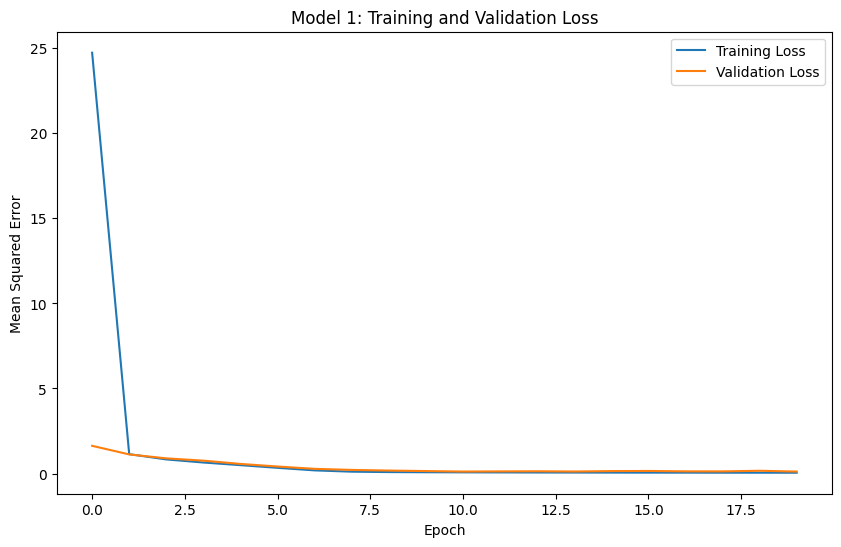

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history_single_layer.history['loss'], label='Training Loss')
plt.plot(history_single_layer.history['val_loss'], label='Validation Loss')
plt.title('Model 1: Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.show()

# second mlp model with two hidden layers 64 and 32 nodes and adam optimizer

In [ ]:
model_two_layers = keras.Sequential([layers.Dense(64, activation='relu', input_shape=(input_dim,)),layers.Dense(32, activation='relu'),layers.Dense(1)])
model_two_layers.compile(optimizer='adam',loss='mean_squared_error',metrics=['mean_absolute_error'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# training the second mlp model for 40 epochs

In [ ]:
history_two_layers = model_two_layers.fit(X_train_scaled, y_train_log,epochs=40,batch_size=32,validation_data=(X_val_scaled, y_val_log),verbose=1)

Epoch 1/40
507/507 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 54.8607 - mean_absolute_error: 5.2894 - val_loss: 0.6600 - val_mean_absolute_error: 0.6421
Epoch 2/40
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4322 - mean_absolute_error: 0.5151 - val_loss: 0.2975 - val_mean_absolute_error: 0.4232
Epoch 3/40
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1111 - mean_absolute_error: 0.2604 - val_loss: 0.1654 - val_mean_absolute_error: 0.3120
Epoch 4/40
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0805 - mean_absolute_error: 0.2213 - val_loss: 0.1258 - val_mean_absolute_error: 0.2772
Epoch 5/40
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0727 - mean_absolute_error: 0.2104 - val_loss: 0.1338 - val_mean_absolute_error: 0.2936
Epoch 6/40
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0701 - mean_absolute_error: 0.2060 - val_loss: 0.1549 - val_mean_absolute_error: 0.3251
Epoch 7/40
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0659 - mean_absolute_error: 0.1980 - 

# evaluating the second mlp model

In [ ]:
loss_two_layers, mae_two_layers = model_two_layers.evaluate(X_val_scaled, y_val_log, verbose=0)
print(f"Two Hidden Layers Model - Validation Loss (MSE): {loss_two_layers:.4f}, Validation MAE: {mae_two_layers:.4f}")

Two Hidden Layers Model - Validation Loss (MSE): 0.1855, Validation MAE: 0.3928


# visualizing results

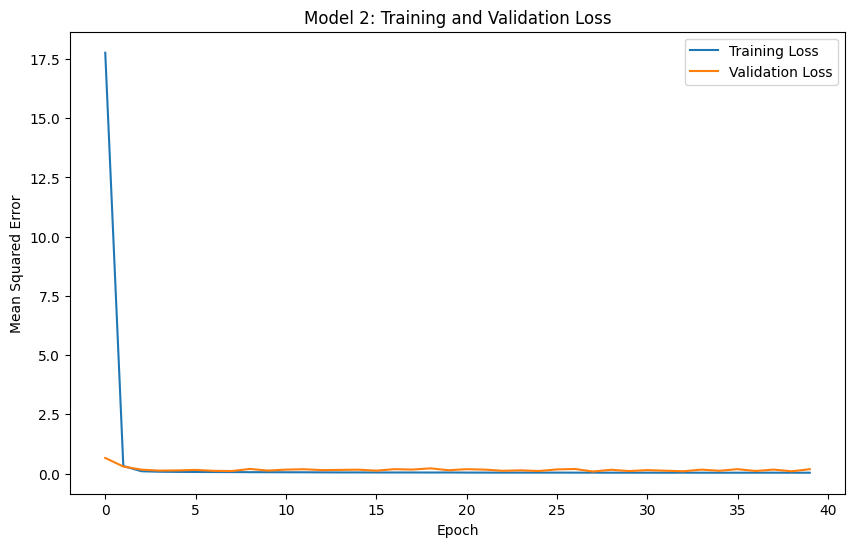

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history_two_layers.history['loss'], label='Training Loss')
plt.plot(history_two_layers.history['val_loss'], label='Validation Loss')
plt.title('Model 2: Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.show()

# comparing models

In [ ]:
print(f"Single Hidden Layer Model - Validation Loss (MSE): {loss_single_layer:.4f}, Validation MAE: {mae_single_layer:.4f}")
print(f"Two Hidden Layers Model - Validation Loss (MSE): {loss_two_layers:.4f}, Validation MAE: {mae_two_layers:.4f}")

Single Hidden Layer Model - Validation Loss (MSE): 0.1147, Validation MAE: 0.2765
Two Hidden Layers Model - Validation Loss (MSE): 0.1855, Validation MAE: 0.3928


# convert back to original scale

In [ ]:
# predictions
y_pred_log_single_layer = model_single_layer.predict(X_val_scaled)
y_pred_log_two_layers = model_two_layers.predict(X_val_scaled)

# original scale
y_pred_single_layer = np.expm1(y_pred_log_single_layer)
y_pred_two_layers = np.expm1(y_pred_log_two_layers)
y_val_original = np.expm1(y_val_log)

mae_single_layer_original = mean_absolute_error(y_val_original, y_pred_single_layer)
mae_two_layers_original = mean_absolute_error(y_val_original, y_pred_two_layers)

print(f"Single Hidden Layer Model - Validation MAE on original scale: {mae_single_layer_original:.4f}")
print(f"Two Hidden Layers Model - Validation MAE on original scale: {mae_two_layers_original:.4f}")


169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Single Hidden Layer Model - Validation MAE on original scale: 137796.7635
Two Hidden Layers Model - Validation MAE on original scale: 180602.4248


# visualizing prediction and real price for the better model which is the one with one hidden layer

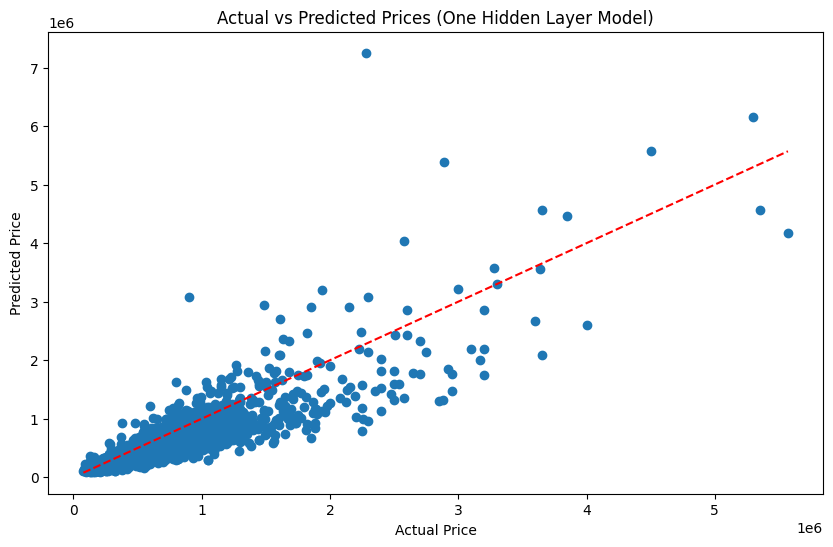

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_val_original, y_pred_single_layer)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices (One Hidden Layer Model)')
plt.plot([y_val_original.min(), y_val_original.max()], [y_val_original.min(), y_val_original.max()], 'r--')
plt.show()

# selecting 5 random data points form the validation set and looking at results

In [ ]:
random.seed(42)

# selecting five random data
val_indices = X_val_encoded.index.tolist()
random_indices = random.sample(val_indices, 5)
X_sample = X_val_encoded.loc[random_indices]
y_sample = y_val.loc[random_indices]

# scale the selected data points
X_sample_scaled = scaler_val.transform(X_sample)

# doing the prediction using the better model

In [ ]:
# using the better model
better_model = model_single_layer
y_pred_log_sample = better_model.predict(X_sample_scaled)

# back to original scale
y_pred_sample = np.expm1(y_pred_log_sample)
y_actual_sample = y_sample.values

results_df = pd.DataFrame({'Actual Price': y_actual_sample,'Predicted Price': y_pred_sample.flatten()})
print("Price Predictions for Selected Data Points:")
print(results_df)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Price Predictions for Selected Data Points:
   Actual Price  Predicted Price
0      225000.0     168905.53125
1      550000.0     519860.06250
2      863000.0     973842.81250
3      280000.0     255573.71875
4      350000.0     268727.34375


# using early stopping

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
# Retrain the better model
history_two_layers_es = better_model.fit(X_train_scaled, y_train_log,epochs=100,batch_size=64,validation_data=(X_val_scaled, y_val_log),callbacks=[early_stopping],verbose=1)

Epoch 1/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0401 - mean_absolute_error: 0.1510 - val_loss: 0.1534 - val_mean_absolute_error: 0.3383
Epoch 2/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0395 - mean_absolute_error: 0.1489 - val_loss: 0.1540 - val_mean_absolute_error: 0.3401
Epoch 3/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0388 - mean_absolute_error: 0.1478 - val_loss: 0.1436 - val_mean_absolute_error: 0.3246
Epoch 4/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0389 - mean_absolute_error: 0.1471 - val_loss: 0.1560 - val_mean_absolute_error: 0.3420
Epoch 5/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0395 - mean_absolute_error: 0.1485 - val_loss: 0.1377 - val_mean_absolute_error: 0.3172
Epoch 6/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0390 - mean_absolute_error: 0.1474 - val_loss: 0.1313 - val_mean_absolute_error: 0.3062
Epoch 7/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0387 - mean_absolute_error: 0.1

# comparing the retrained model and the original

In [ ]:
y_pred_log_sample_es = better_model.predict(X_sample_scaled)
y_pred_sample_es = np.expm1(y_pred_log_sample_es)
results_df['Predicted Price (Retrained Model)'] = y_pred_sample_es.flatten()
print("Price Predictions for Selected Data Points (Retrained Model):")
print(results_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Price Predictions for Selected Data Points (Retrained Model):
   Actual Price  Predicted Price  Predicted Price (Retrained Model)
0      225000.0     168905.53125                       165565.78125
1      550000.0     519860.06250                       532825.56250
2      863000.0     973842.81250                       906557.68750
3      280000.0     255573.71875                       255904.68750
4      350000.0     268727.34375                       320414.81250
